# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [5]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
plans. info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: De la tabla usage se evidencia que las columnas duration, length contienen un 55% y un 44% de valores nulos o faltantes, de la tabla users la columna city presenta un 11% de valores nulos 

💡 **Nota:** Se procede a identificar porque se tiene esta cantidad de valores nulos y volveremos a evaluar 
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


- La columna `user_id` es de tipo Int64 osea tipo numerico entero
- La columna `age` es de tipo Int64 osea tipo numerico entero, hay que hacer el cambio a tipo fecha ya que habalmaos de una edad asi mismo con la columna `reg_date` es de tipo fecha por ende hay que cambiar estos datos posteriormente a tipo fecha

In [15]:
usage.info()
usage.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


- Las columnas `id` y `user_id` son de tipo Int64 osea numerico entero
- Las columnas `duration` y `length` son de tipo float64 osea numerico decimal 

In [16]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].value_counts()
print(users['city'].unique())
print(columnas_user)

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` presenta 8 registros unicos pero contiene datos con "?" y registros vacios 
- La columna `plan` presenta dos registros "Basico" y "Premium"

In [17]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` nos muestra dos registros si es "call" o "text"


---
✍️ **Comentario**: Se detectan sentinels en la columna "City" se recomienda revisar los datos para ver si hay coincidencia con algun dato e identificar de que ciudad son estos datos, si no se encuentra una coincidencia se recomienda eliminar dichos datos 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [20]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date` los registros van desde 2022 a 2026

In [21]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date` solo se encuentran registros de 2024 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: En reg_date tenemos datos de 2022 a 2024 y en date solo de 2024 por ende solo debemos trabajar con los datos de 2024 en reg_date para poder hacer un analisis consecuente con las fechas 

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?",pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para durati
usage['duration'].isna().groupby(usage['type']).sum()


type
call        0
text    22076
Name: duration, dtype: int64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()


type
call    17896
text        0
Name: length, dtype: int64

Los nulos en `duration` y `length` son de tipo  MNAR (Missing Not At Random) los datos no faltan por error, sino porque por diseño no corresponden a ese tipo de evento.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,id,duration,length,is_text,is_call
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns = {"is_text" : "cant_mensajes" , "is_call" : "cant_llamadas" , "duration" : "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on = ['user_id'], how = 'inner')
user_profile = user_profile[['user_id','id','first_name','last_name','city','plan','age','reg_date','cant_llamadas','cant_minutos_llamada','cant_mensajes','length','churn_date']]
user_profile.head(5)

,user_id,id,first_name,last_name,city,plan,age,reg_date,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,churn_date
0,10000,236778,Carlos,Garcia,Medellín,Basico,38.0,2022-01-01 00:00:00.000000000,3,23.70,7,258.0,NaN
1,10001,296458,Mateo,Torres,<NA>,Basico,53.0,2022-01-01 06:34:17.914478619,10,33.18,5,226.0,NaN
2,10002,111444,Sofia,Ramirez,CDMX,Basico,57.0,2022-01-01 13:08:35.828957239,2,10.74,5,225.0,NaN
3,10003,289686,Mateo,Ramirez,Bogotá,Premium,69.0,2022-01-01 19:42:53.743435858,3,8.99,11,530.0,NaN
4,10004,199943,Mateo,Torres,GDL,Basico,63.0,2022-01-02 02:17:11.657914478,3,8.01,4,229.0,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_llamadas','cant_minutos_llamada','cant_mensajes','length']].describe()


,age,cant_llamadas,cant_minutos_llamada,cant_mensajes,length
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,4.478120,23.317054,5.524381,288.128032
std,17.692032,2.144238,18.168095,2.358416,180.906841
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,11.120000,4.000000,184.000000
50%,47.000000,4.000000,19.780000,5.000000,268.000000
75%,63.000000,6.000000,31.415000,7.000000,361.000000
max,79.000000,15.000000,155.690000,17.000000,2028.000000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

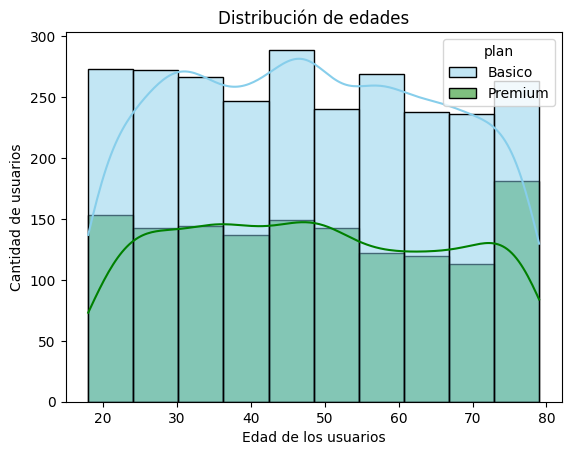

In [45]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x = 'age' , bins=10, palette=['skyblue','green'], hue ='plan', kde=True)

plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edades')

plt.show()

💡Insights: 
- Distribución simetrica en donde se evidencia un numero regular de usuarios por edades
- Se evidencia una cantidad de usaurios con una edad de 47 años

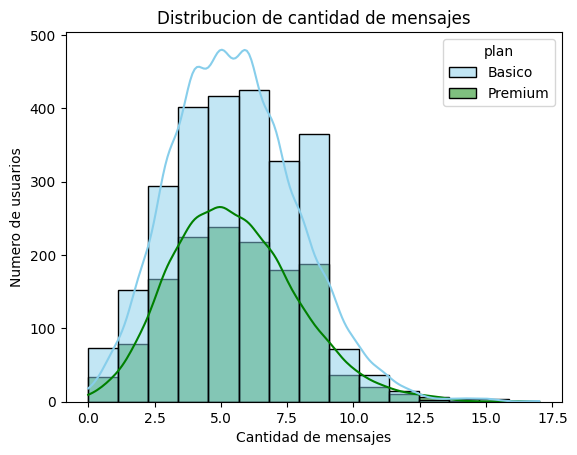

In [50]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x = 'cant_mensajes' , bins=15, palette=['skyblue','green'], hue ='plan', kde=True)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Numero de usuarios')
plt.title('Distribucion de cantidad de mensajes')

plt.show()

💡Insights: 
- Distribucion sesgada a la derecha en donde se evidencia dentro de la grafica que tenemos una distribucion con pocos outliers lo que hace alargar nuestra grafica lo que nos dice que muy pocos usurios tienen una cantidad de mensajes mayores a 15
- Tenemos una tendencia dentro de nuestros usuarios con una cantidad de mensajes entre 5.0 a 6.0

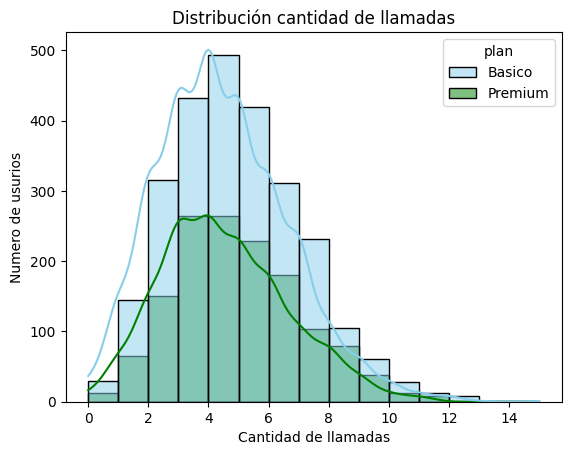

In [52]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x = 'cant_llamadas' , bins=15, palette=['skyblue','green'], hue ='plan', kde=True)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Numero de usurios')
plt.title('Distribución cantidad de llamadas')

plt.show()

💡Insights: 
- Distribución sesgada a la derecha con pocos outliers donde podemos ver una curva bien marcada con una pequeña ampliacion a la derecha adicional evidenciamos un comportamiento de un 60/40 por los diferentes planes que tenemos

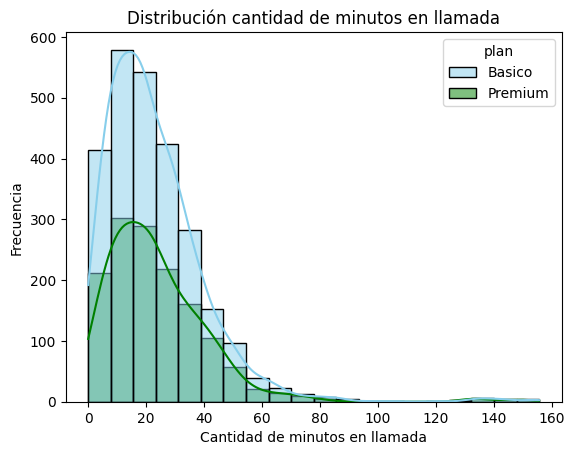

In [53]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x = 'cant_minutos_llamada' , bins=20, palette=['skyblue','green'], hue ='plan', kde=True)

plt.xlabel('Cantidad de minutos en llamada')
plt.ylabel('Frecuencia')
plt.title('Distribución cantidad de minutos en llamada')

plt.show()

💡Insights: 
- Distribucion sesgada a la derecha en donde encontramos muchisimos outliers que nos muestra que tenemos muchos usuarios que duran mas de una hora en llamadas
- El comportamiento de los usuarios es casi simetrico mirando los planes con los que contamos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

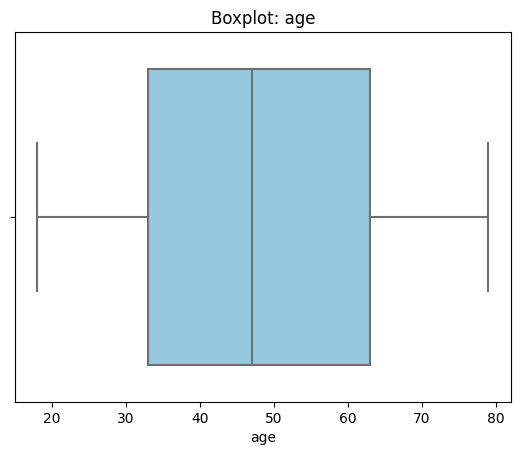

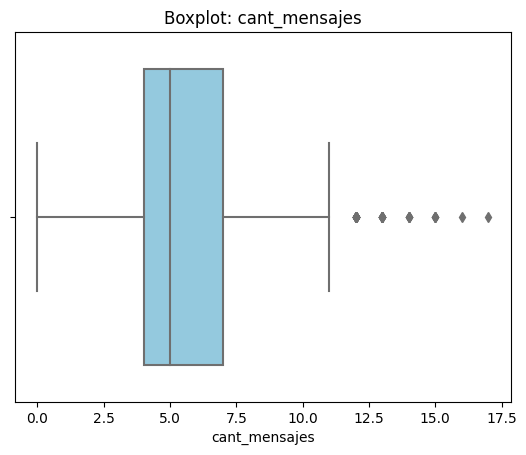

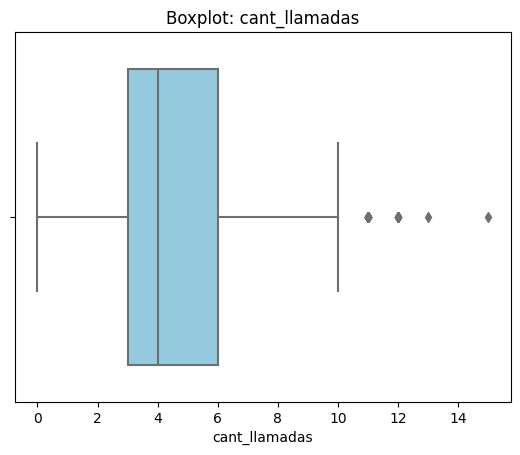

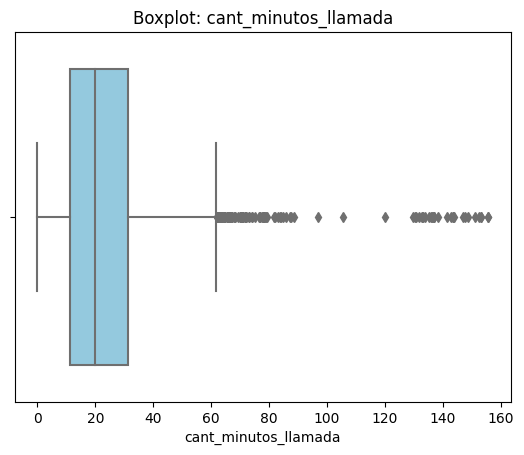

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'] 
for col in columnas_numericas : 
    sns.boxplot(x= user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()
    

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: presenta 6 outliers segun la grafica, esto confirma la distribucion de nuestras graficas anteriores ya que tenemos una distribucion simetrica con un poco alargamiento a la derecha 
- cant_llamadas: presenta 4 outliers segun la grafica, esto confirma la distribucion de nuestras graficas anteriores ya que tenemos una distribucion simetrica con un poco alargamiento a la derecha 
- cant_minutos_llamada: Contiene demasiados outliers, tenemos un promedio cercano a 20 minutos pero contamos con una gran cantidad de usuarios con duracion en llamadas con mas de una hora 

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites :
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    print(col, "lower:", lower, "upper:", upper)



age lower: -12.0 upper: 108.0
cant_mensajes lower: -0.5 upper: 11.5
cant_llamadas lower: -1.5 upper: 10.5
cant_minutos_llamada lower: -19.322500000000005 upper: 61.8575


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantengo los outliers ya que con las graficas identificamos que son pocos usuarios con una cantidad de mensajes fuera de lo comun pero estos datos nos muestran un comportamiento real de nuestros usuarios, evidenciamos usuarios que les gusta mas los mensajes que las llamadas
- cant_llamadas: Mantengo los outliers ya que con las graficas identificamos que son pocos usuarios con una cantidad de llamadas fuera de lo comun pero estos datos nos muestran un comportamiento real de nuestros usuarios, evidenciamos usuarios que les gusta mas las llamadas que los mensajes
- cant_minutos_llamada: Mantengo los outliers, ya que esta variable esta dada a mucha variacion dependiendo del usuario pero muestra un comportamiento real 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes']  < 5) , "Bajo uso", np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes']  < 10), "Uso medio", "Alto uso"))



In [40]:
# verificar cambios
user_profile.head()

,user_id,id,first_name,last_name,city,plan,age,reg_date,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,churn_date,grupo_uso
0,10000,236778,Carlos,Garcia,Medellín,Basico,38.0,2022-01-01 00:00:00.000000000,3,23.70,7,258.0,NaN,Uso medio
1,10001,296458,Mateo,Torres,<NA>,Basico,53.0,2022-01-01 06:34:17.914478619,10,33.18,5,226.0,NaN,Alto uso
2,10002,111444,Sofia,Ramirez,CDMX,Basico,57.0,2022-01-01 13:08:35.828957239,2,10.74,5,225.0,NaN,Uso medio
3,10003,289686,Mateo,Ramirez,Bogotá,Premium,69.0,2022-01-01 19:42:53.743435858,3,8.99,11,530.0,NaN,Alto uso
4,10004,199943,Mateo,Torres,GDL,Basico,63.0,2022-01-02 02:17:11.657914478,3,8.01,4,229.0,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def agrupacion_edades(row):
    edad = row["age"]
    if edad < 30:
        return "Joven" 
    elif edad < 60 :
        return "Adulto"
    else: 
        return "Adulto Mayor"
    
user_profile["grupo_edad"] = user_profile.apply(agrupacion_edades, axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,id,first_name,last_name,city,plan,age,reg_date,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,churn_date,grupo_uso,grupo_edad
0,10000,236778,Carlos,Garcia,Medellín,Basico,38.0,2022-01-01 00:00:00.000000000,3,23.70,7,258.0,NaN,Uso medio,Adulto
1,10001,296458,Mateo,Torres,<NA>,Basico,53.0,2022-01-01 06:34:17.914478619,10,33.18,5,226.0,NaN,Alto uso,Adulto
2,10002,111444,Sofia,Ramirez,CDMX,Basico,57.0,2022-01-01 13:08:35.828957239,2,10.74,5,225.0,NaN,Uso medio,Adulto
3,10003,289686,Mateo,Ramirez,Bogotá,Premium,69.0,2022-01-01 19:42:53.743435858,3,8.99,11,530.0,NaN,Alto uso,Adulto Mayor
4,10004,199943,Mateo,Torres,GDL,Basico,63.0,2022-01-02 02:17:11.657914478,3,8.01,4,229.0,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

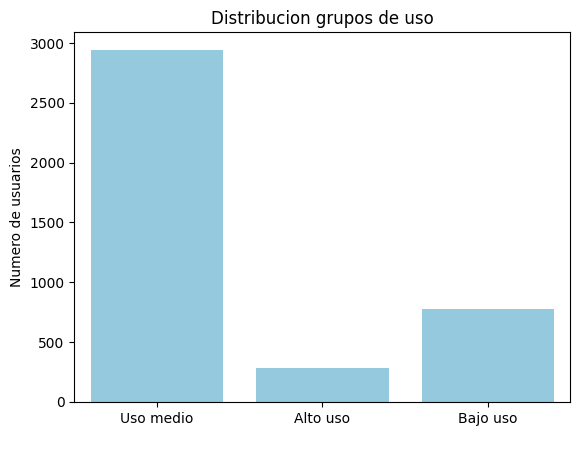

In [57]:
# Visualización de los segmentos por uso
sns.countplot(x= user_profile['grupo_uso'], color='skyblue')
plt.title("Distribucion grupos de uso")
plt.ylabel("Numero de usuarios")
plt.xlabel(" ")
plt.show()


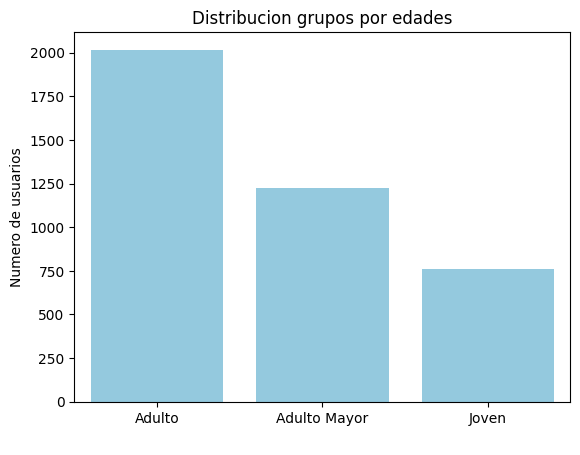

In [44]:
# Visualización de los segmentos por edad
sns.countplot(x= user_profile['grupo_edad'], color='skyblue')
plt.title("Distribucion grupos por edades")
plt.ylabel("Numero de usuarios")
plt.xlabel(" ")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
      Evidenciamos erorres en el tipo de dato que teniamos dentro del datafreme, tambien sentinels dentro de age y sentinels en reg_date donde tenemos fechas fuera de rango para el analisis 

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
      identificamos los diferentes grupos de edades en donde evidenciamos que al menos el 50% de nuestros usuarios son adultos por lo que se recomienda centrarse en este grupo y tambien evidenciar que el grupo de jovenes es un grupo el cual podemos explotar ya que es el grupo con menos usurios dentro de nuestro analisis, tambien destacar que el uso medio es el mas destacado dentro de nuestros usuarios

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
      Los adultos con uso medio del telefono ya que mas de la mitad de los datos de nuestro analisis pertenecen a este grupo

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
      Encontre muchos outliers en la cantidad de minutos en llamada lo que nos dice que muchos usuarios duran mas de 60 min en llamadas y nos muestra un comportamiento natural dentro de nuestra sociedad y esto nos representa una oportunidad para realizar beneficios para estos usuarios que duran mas en el telefono (Es importante saber el modelo de negocio que tiene ConnecTel ya que no cuento con la informacion necesarios, si se le cobra al usuario un numero de minutos al mes, se les cobra por minuto en llamada o son planes ilimitados, si corresponde a los primeros dos planes podemos dar beneficios para que la gente dure mas en el telefono y asi ganar mas o incentivar a un mayos uso en llamadas y mnesajes)

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
     Recomendaria planes para los usuarios con mayor duracion en las llamadas que vean beneficios para seguir hablando por telefono y mantener esta distribucion en el tiempo ya que la gente que habla poco por telefono son personas que pueden preferir los mensajes por encima de las llamadas y no vean bien un incentivo para hablar mas por telefono
     Buscaria usuarios que trabajen con sus telefonos, asesores de ventas, emprendedores que reciban o realicen muchas llamadas para ofrecer estos planes con beneficios por sus profesiones 

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`